In [636]:
%reload_ext autoreload
%autoreload 2
import phasecheck as pc
import sxmreader as sxm
import trackpy as tp
import matplotlib.pyplot as plt
from PIL import Image
from sxmreader import SXMReader
import numpy as np
import pandas as pd
from scipy.signal import find_peaks
from phasecheck import get_cffits

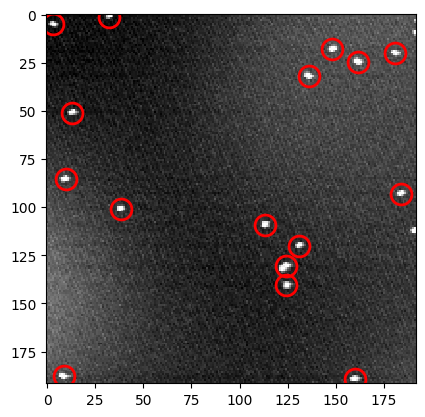

<AxesSubplot:>

In [111]:
#Getting data with SXM

path=['test_images/Image_900.sxm']
img = SXMReader(path, correct='lines')[0]
_kwargs={
    'diameter':5,
    'maxsize':200,
    'minmass':1,
    'separation':2,}
fs = tp.locate(img,**_kwargs) #gets data
tp.annotate(fs,img) #plots image with the red circles


/Users/lucnguyen/opt/anaconda3/envs/venv/lib/python3.7/site-packages/ipykernel_launcher.py:10: DeprecationWarning: ANTIALIAS is deprecated and will be removed in Pillow 10 (2023-07-01). Use LANCZOS or Resampling.LANCZOS instead.
  # Remove the CWD from sys.path while we load stuff.


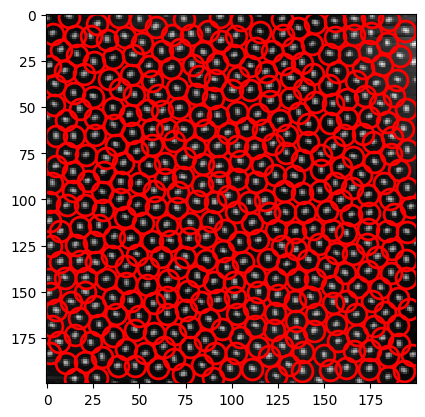

<AxesSubplot:>

In [109]:
#Getting data with jpg/png
path=['test_images/Image_924 Image Z (m).jpg']
_kwargs={
    'diameter':5,
    'maxsize':200,
    'minmass':1,
    'separation':2,}
img = Image.open(path[0])
#This part just to get img readable for trackpy
img = img.resize((200,200), Image.ANTIALIAS)
img=img.convert('L')
img.ndim=2
img.shape=img.size

fs=tp.locate(img,**_kwargs).reset_index()
tp.annotate(fs,img)


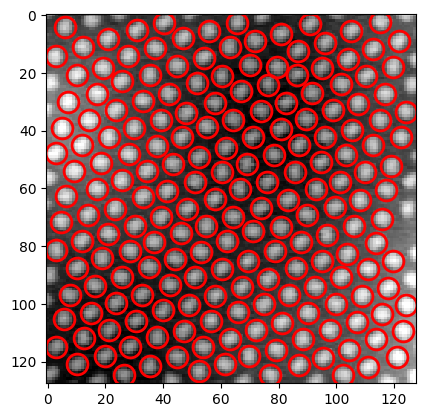

density=7.920000E+12
popt_constfunc (r2=1.1102e-16, rmse=0.1759+6.2456e-21j): [0.09751832]
popt_pwrlawdecay (r2=0.96412, rmse=0.033318+2.3395e-19j): [6.20098993e+19 3.64545820e-02 2.78478257e+01]
popt_expdecay (r2=0.92766, rmse=0.047308+2.4857e-19j): [222.86335506   0.88347149]



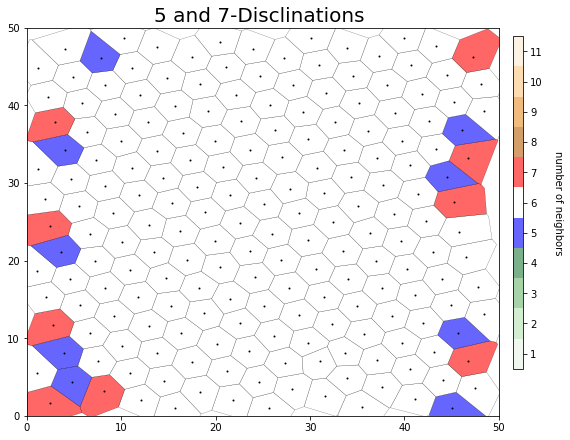

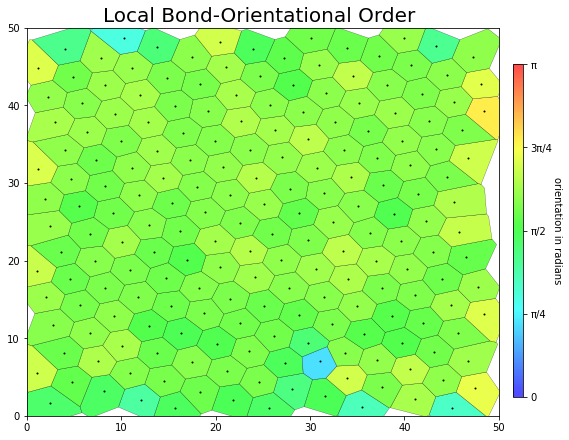

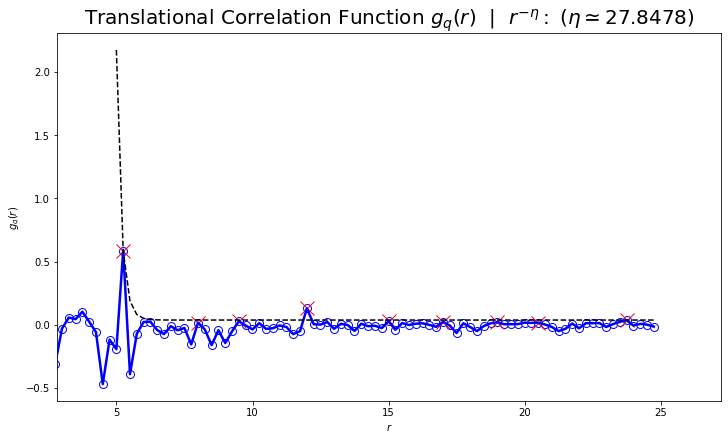

popt_constfunc (r2=2.2204e-16, rmse=0.024541+1.4215e-18j): [0.73341939]
popt_pwrlawdecay (r2=0.95283, rmse=0.0053299+5.094e-19j): [ 1.58133942 -0.70283274  0.03720085]
popt_expdecay (r2=0.95032, rmse=0.0054697+2.5363e-19j): [  0.79555497 178.62477092]

winner: power law fit



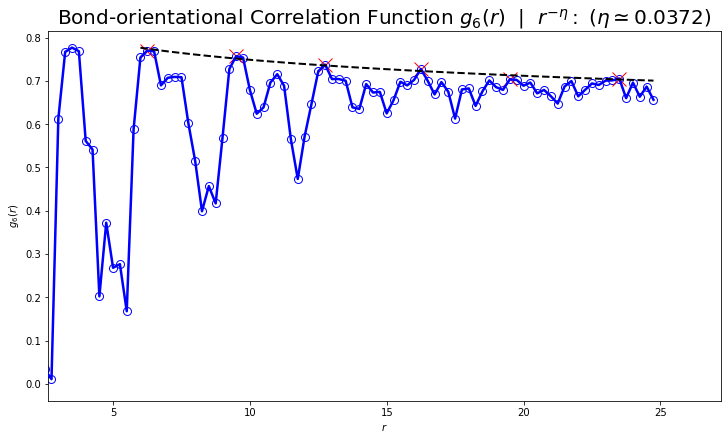

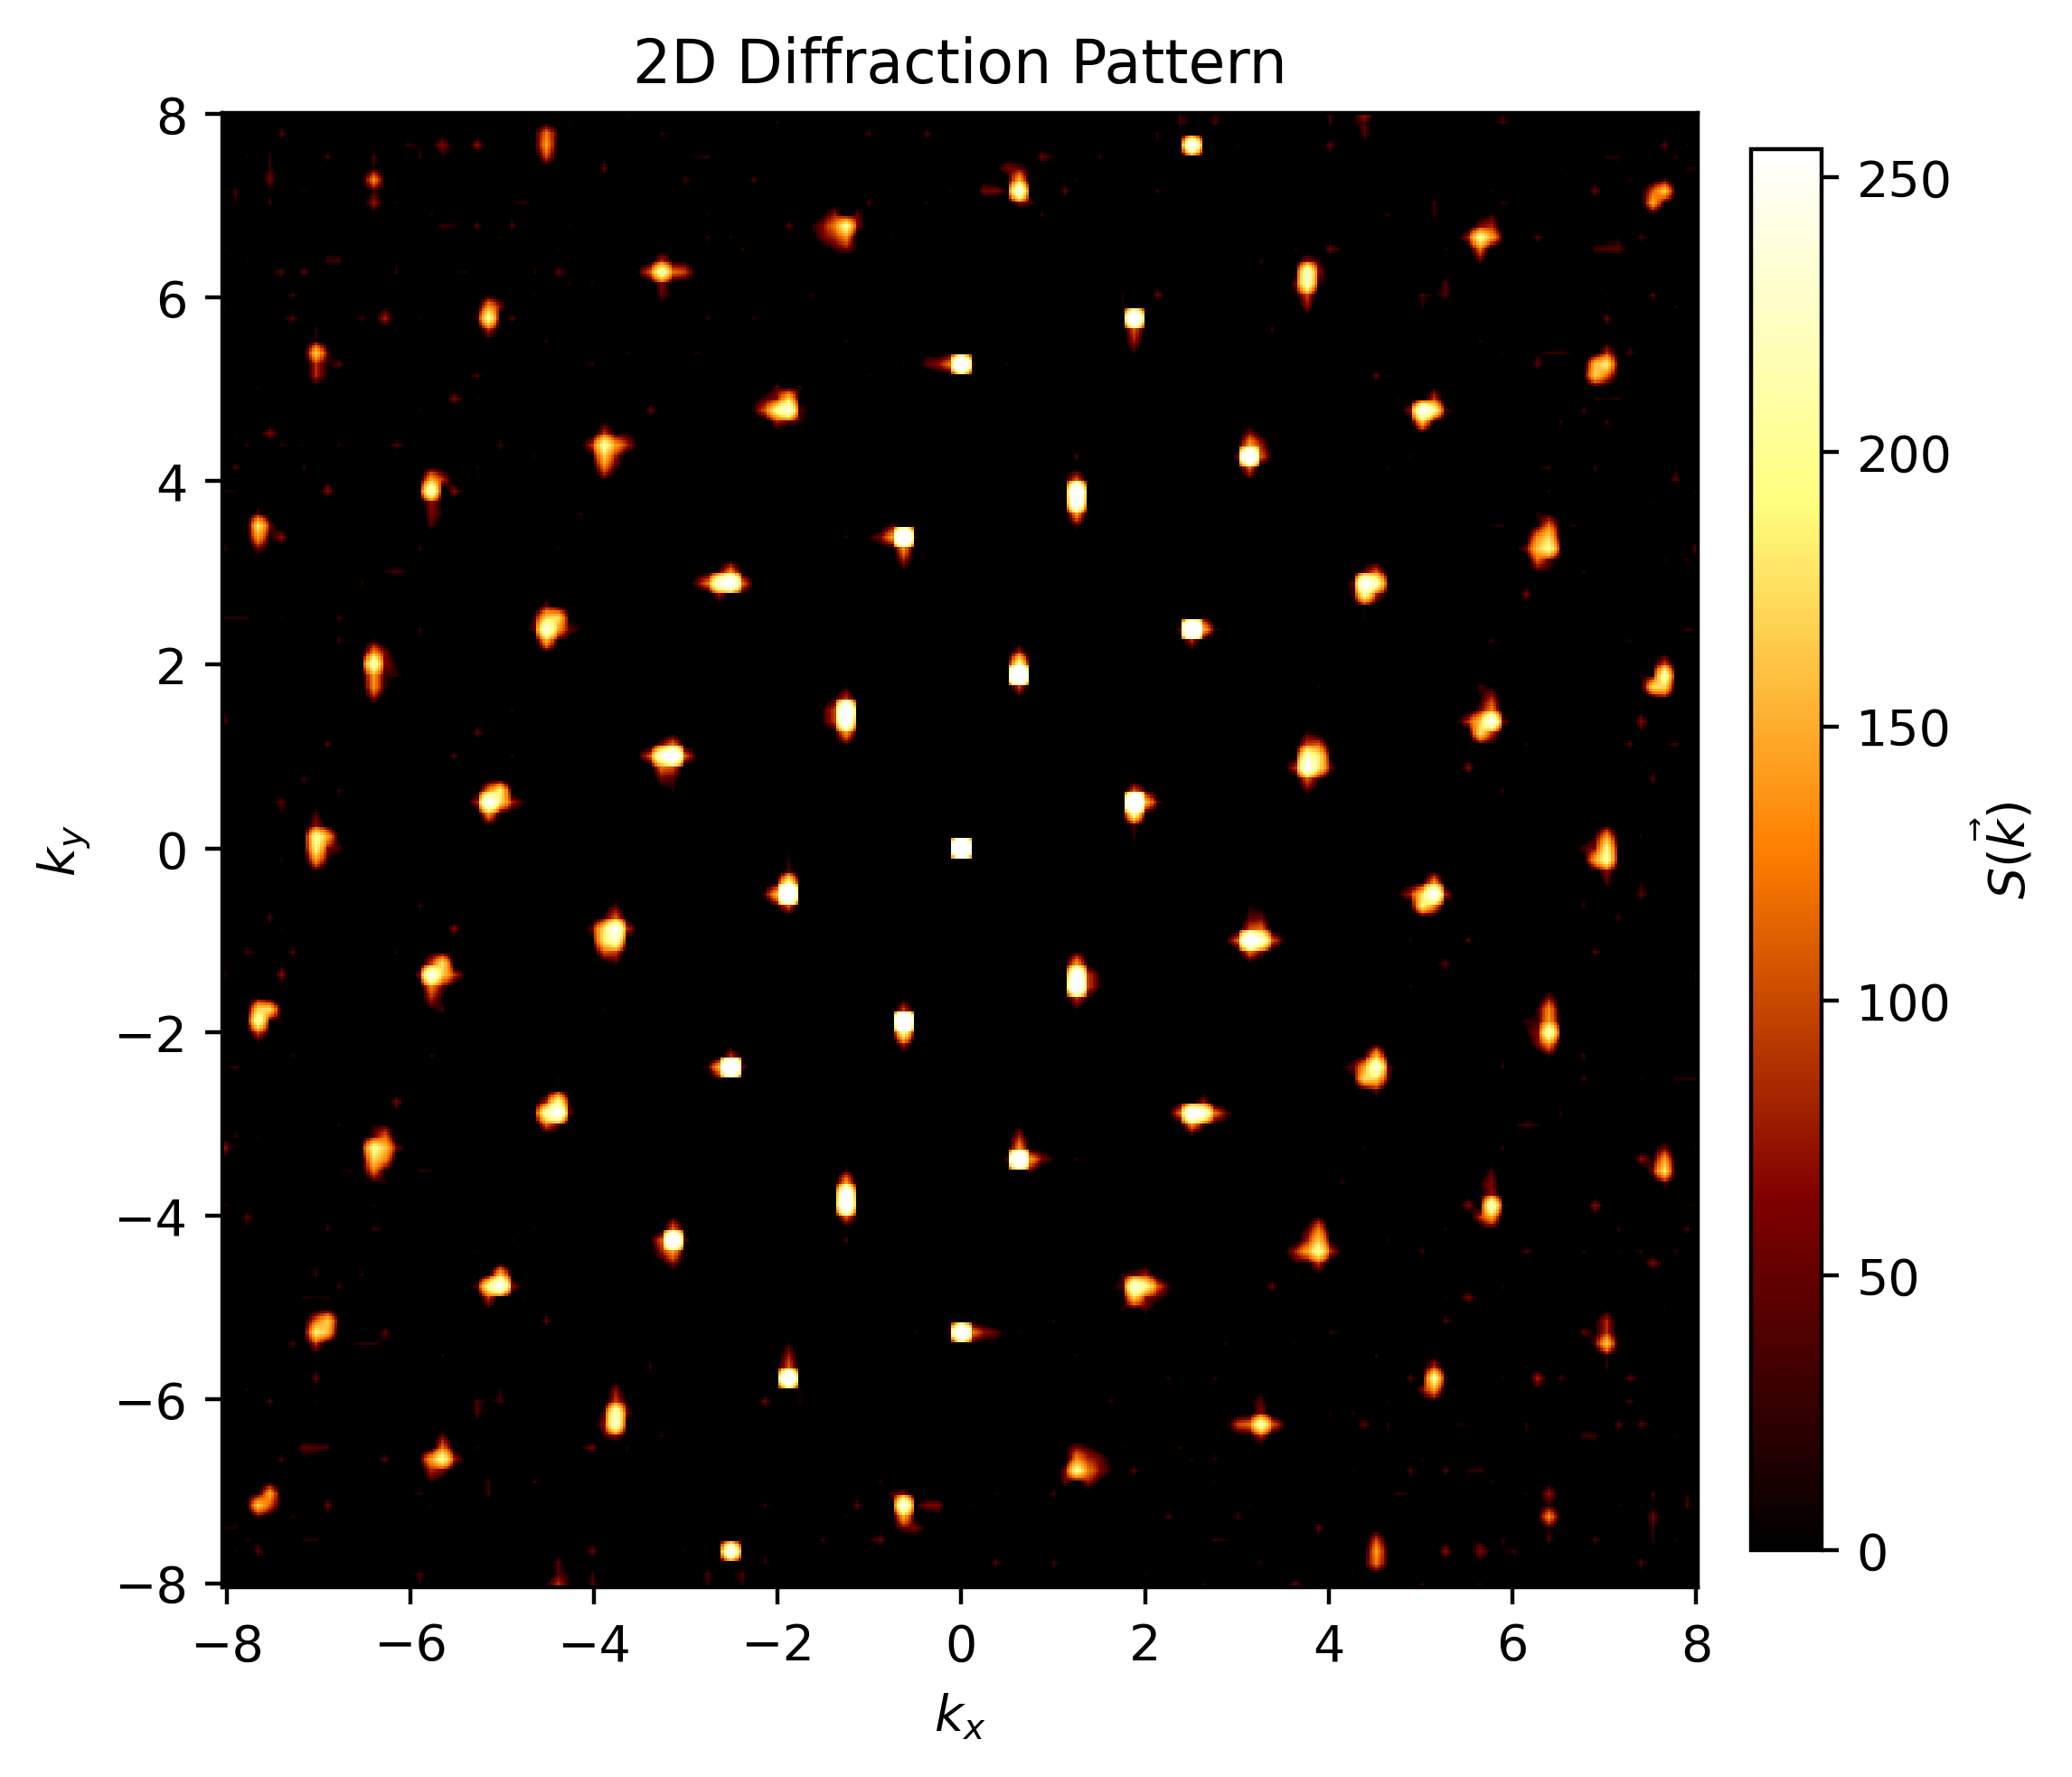

In [650]:
#The two cells above are esentially done when initializing a 
#phasecheck.imgdata instance

_kwargs={
    'diameter':7,
    'maxsize':300,
    'minmass':2,
    'separation':6
    
    ,}

path=[f'test_images/Image_668.sxm']
img_d=pc.imgdata(path,filetype='SXM',**_kwargs)
tp.annotate(img_d.data,img_d.img)
#SXM files have scan dimensions in meters
xdim=SXMReader(path).scans[0].size['real']['x']*100 
ydim=SXMReader(path).scans[0].size['real']['y']*100

density=img_d.data.shape[0]/(xdim*ydim) #calculate density
print(f'density={density:E}')

#plots Voronoi diagram, kind=0 for nearest neighbor
pc.plot_boops(img_d,kind=0,realdim=True) 

#kind=1 for orientation
pc.plot_boops(img_d,kind=1,realdim=True) 

#start and dist choose starting point and distance between peaks,
#fit_id=None for best fit, 0,1,2 to choose what curve

#translational order 
pc.plot_tocf(img_d,start=1,fit_id=1,realdim=True,dist=6)

#orientational order 
pc.plot_bocf(img_d,start=1,fit_id=None,realdim=True,dist=8)

#pc.plot_rdf(img_d,start=1,fit_id=None)


#structure factor
pc.plot_ssf2(img_d,upper=0.2,lower=0.01,grid_size=512,dpi=400,realdim=True)



In [ ]:
def find_recip_vector(img_d,radius,realdim=False,grid_size=512,lower=0.01,upper=1):
    if realdim==False:
        xdim, ydim = img_d.img.shape
        xscale=1
        yscale=1
    else:
        if img_d.sxm==True:
            xdim=img_d.dims[0]
            ydim=img_d.dims[1]
        else:
            xdim=realdim[0]
            ydim=realdim[1]
        xscale=xdim/img_d.img.shape[0]
        yscale=ydim/img_d.img.shape[1]
    xydata=np.array([[img_d.data['x'][i]*xscale,img_d.data['y'][i]*yscale] for i in range(img_d.data['x'].size)  ])
    points =np.array([[img_d.data['x'][i]*xscale,img_d.data['y'][i]*yscale,0] for i in range(img_d.data['x'].size)  ])
    points=points-points[1]
    box3d = freud.Box.cube(L=xdim) 
    ssf =  freud.diffraction.DiffractionPattern(grid_size=grid_size)
    ssf.compute(system=(box3d, points))
    ssfmin, ssfmax = np.min(ssf.k_values), np.max(ssf.k_values)

    data=ssf.diffraction
# Define the center coordinates
    center_x = data.shape[0] // 2
    center_y = data.shape[1] // 2

# Define the radius of the center circle
    center_radius = radius/ssfmax*(grid_size/2)  # Adjust this value as needed

# Create a grid of distances from the center
    x, y = np.ogrid[:data.shape[0], :data.shape[1]]
    distances = np.sqrt((x - center_x)**2 + (y - center_y)**2)

# Create a circular mask to exclude the center region
    mask = distances <= center_radius

# Apply the mask to the array and find the maximum value
    max_value = np.max(data[~mask])
    peaks=(np.array(np.where(np.abs(max_value-data)<1,))-grid_size/2)*ssfmax/(grid_size/2)

    extent=[ssfmin, ssfmax, ssfmin, ssfmax]
    ssf_vals=ssf.to_image(cmap='afmhot',vmin=lower*ssf.N_points,vmax=upper*ssf.N_points)
    
    fig, ax = plt.subplots(1, 1, facecolor='w', constrained_layout=True,)
    sfax = ax.imshow(ssf_vals, origin='lower', cmap='afmhot', extent=[ssfmin, ssfmax, ssfmin, ssfmax])
    ax.set(xlabel=r'$k_{x}$', ylabel=r'$k_{y}$', title=r'2D Diffraction Pattern')
    ax.scatter(peaks[0,:],peaks[1,:])
    return peaks,ssf,fig


def plot_tocf2(img_d,g, bins=100,realdim=False, fit_id=None,
 dist=6,dpi=72,savename=False,filetype='svg',xtype='linear',
               ytype='linear',start=1,r2fit=1):
    if realdim==False:
        xdim, ydim = img_d.img.shape
        xscale=1
        yscale=1
    else:
        if img_d.sxm==True:
            xdim=img_d.dims[0]
            ydim=img_d.dims[1]
        else:
            xdim=realdim[0]
            ydim=realdim[1]
        xscale=xdim/img_d.img.shape[0]
        yscale=ydim/img_d.img.shape[1]

     
    xydata=np.array([[img_d.data['x'][i]*xscale,img_d.data['y'][i]*yscale] for i in range(img_d.data['x'].size)  ])
    points =np.array([[img_d.data['x'][i]*xscale,img_d.data['y'][i]*yscale,0] for i in range(img_d.data['x'].size)  ])
    points=points-points[1]
    box = freud.box.Box(Lx=xdim, Ly=ydim, Lz=0, is2D=True)
    cf = freud.density.CorrelationFunction(bins=bins, r_max=ydim/3)
    cf_vals = []
    g_3d=np.concatenate([g,[0]])
    torder_complex = np.exp(1j*np.dot(points,g_3d))
    cf.compute(system=(box, points), values=torder_complex,)
    cf_edges = cf.bin_edges[:-1] #/ sigma
    cf_vals=cf.correlation
    
    fig, ax = plt.subplots(figsize=(10, 6), facecolor='w', constrained_layout=True, dpi=dpi)
    
    ax.plot(cf_edges, cf_vals, 'o', ms=8, c='w', mec='b', zorder=2)
    ax.plot(cf_edges, cf_vals, lw=2.5, c='b', zorder=3) 
    
    cfpks = find_peaks(cf_vals, distance=dist)[0]
    idxlim = np.argwhere(cf_edges == cf_edges[cfpks][start])[0][0]-1
    ax.plot(cf_edges[cfpks[start:]], cf_vals[cfpks[start:]], 'x', c='r', ms=14)
    
    fit_func, popt, fit_text = get_cffits(
        cf_edges[cfpks[start:]],
        cf_vals[cfpks[start:]], fit_id,r2fit=r2fit,expconstant=True)
    ax.plot(cf_edges[idxlim:], fit_func(cf_edges[idxlim:], *popt), '--', lw=1.5, c='k', zorder=9)
    
    ax.set(xlabel=r'$r$', ylabel=f'$g_{{q}}(r)$', title=f'Translational Correlation Function $g_{{q}}(r)$  |  {fit_text}')
    ax.set_title(label=f'Translational Correlation Function $g_{{q}}(r)$  |  {fit_text}',
                fontsize=20)
    ax.set(xlim=(cf_edges[cfpks[0]]*0.75, cf_edges[-1]*1.1))
    ax.set(xscale=xtype)
    ax.set(yscale=ytype)
    if savename!=False:
        fig.savefig(savename, format=filetype)
    return plt.show()
vector,ssf,plot=find_recip_vector(img_d,0.2,grid_size=512,realdim=True)
plot_tocf2(img_d,vector[:,1],fit_id=None,bins=100,realdim=True,start=1,dist=7,)